<span style='font-size:x-large'>**Capstone Project: Analyzing Emissions Patterns from Data Centers in Loudoun County, VA** </span>

<span style='font-size:medium'>**Author:**</span><span style='font-size:medium'> Marjorie Huang</span>

<span style='font-size:medium'>**Date:**</span><span style='font-size:medium'> 2026\-03\-23</span>

<span style='font-size:large'>**Introduction/Background:** </span>

<span style='font-size:medium'>As of 2026, Loudoun County hosts over 209 operational data centers, with an additional 43 facilities under construction, making it the largest concentration of data centers globally. These facilities rely on thousands of diesel backup generators, which emit air pollutants. </span>

<span style='font-size:medium'>These pollutants are associated with environmental concerns, such as smog formation, acid rain, and nutrient deposition that may affect nearby waterways. Given the importance of these local water bodies for drinking water supply, ecosystem health, and economic activity, understanding the cumulative emissions from data centers and how closely these facilities are situated to waterways \- many of which are already deemed impaired \- can help inform planning and regulatory discussions as the industry grows. </span>

<span style='font-size:large'>**Research Questions:**</span><span style='font-size:large'> </span>

<span style='font-size:medium'>\- How many data centers in Loudoun County, Virginia emitted air pollutants in 2024?</span>

<span style='font-size:medium'>\- Which air pollutants are emitted at the highest levels by these data centers?</span>

<span style='font-size:medium'>\- Where are spatial clusters of air pollutant–emitting data centers located within Loudoun County, Virginia?</span>

<span style='font-size:medium'>\- What is the proximity of these data centers to nearby water bodies?</span>

<span style='font-size:medium'>**Link to GitHub repository:**</span><span style='font-size:medium'> </span>[https://github.com/m\-huang25/environmental\-data\-centers](https://github.com/m-huang25/environmental-data-centers) 



<span style='font-size:large'>**Data**</span>: 

<span style='font-size:medium'>**Data center data:**</span><span style='font-size:medium'> Data center location data comes from the Data\_Centers\_Virginia FeatureServer \(ArcGIS REST API\), accessed via the Piedmont Environmental Council website. The FeatureServer provides geospatial data on existing and planned data centers across Virginia. This data set provides the name, address, latitude and longitude of existing and proposed data centers in Loudoun County, VA. This dataset is crowdsourced so there are potential gaps, lags in updates and inconsistencies. </span>

<span style='font-size:medium'>**Acive air site data:**</span><span style='font-size:medium'> from the Virginia Department of Environmental Quality \(DEQ\) Environmental Data Hub. This data set provides the identification number of sites with corresponding names and addresses of air pollutant emitters. The data from the website is only from 2024. </span>

<span style='font-size:medium'>**Air emissions data:**</span><span style='font-size:medium'> from the Virginia Department of Environmental Quality \(DEQ\) Environmental Data Hub. This data set provides the identification number, pollutants and pollutant emission values of air pollutant emitters. The data from the website is only from 2024. </span>

<span style='font-size:medium'>**County border data:**</span><span style='font-size:medium'> from the Loudoun County Office of Mapping and Geographic Information \(OMAGI\). This GeoJSON file contains the spatial geographic boundary of Loudoun County, Virginia.</span>

<span style='font-size:medium'>**Waterbodies data:**</span><span style='font-size:medium'> from the Loudoun County Office of Mapping and Geographic Information \(OMAGI\). This GeoJSON file contains mapped surface water features within Loudoun County, Virginia.</span>

<span style='font-size:medium'>**Cleaning process?**</span>

<span style='font-size:medium'>This project integrates multiple datasets and applies data cleaning to examine air pollutant emissions from data centers. The cleaning process followed the following steps: </span>

<span style='font-size:medium'>First, two datasets were obtained from the Virginia Department of Environmental Quality \(DEQ\): \(1\) a dataset of regulated air emission sites with facility identifiers, data center names and addresses, and \(2\) a dataset of facilty identifiers, data center names and reported pollutant emissions and emission values. The first dataset was filtered to include only existing cities within Loudoun County and data centers/data center\-related words. The variables in both datasets were renamed for consistency with R naming conventions.   Rows were checked for any missing values or N/As within these filtered sets. After cleaning, these datasets were joined using facility identifiers to create a dataframe with facility identifiers, data center names, addresses, pollutants, and air pollutant emission values.</span>

<span style='font-size:medium'>Next, the data center dataset was used to identify data centers' addresses and geographic coordinates. Similar to the previous datasets, variables were renamed for consistency with R naming conventions, and rows were checked for any missing or N/A latitude and longitude coordinates. This dataset was filtered to include only existing facilities within Loudoun County, and addresses were standardized to match the addresses from the joined air emission data sets. </span>

<span style='font-size:medium'>After cleaning, the data center dataset was joined to the above joined datasets by standarized addresses to create a complete dataframe with facility identifiers, data center names, addresses, pollutants, air pollutant emission values, and latitude and longitude coordinates to be able to create spatial visualizations. </span>


In [3]:
#load libraries

library(tidyverse)       
library(ggthemes)   
library(sf)  


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



In [6]:
setwd("/home/user/Capstone/data_center_research")

In [7]:
# Import and clean dataset on air montoring sites in Virginia
air_sites <- read.csv("data/processed/active_air_sites.csv")

# Examine the variables of the dataset
names(air_sites)

# Create new dataframe

air_sites_clean <- as.data.frame(air_sites)

# Rename variables
air_sites_clean <- air_sites %>%
    rename(
      name = PLA_NAME,
      address = FAC_L_ADDR_1,  
      city = FAC_L_CITY,
      principal_product = PLA_PRINCIPAL_PRODUCT,
      icis_id = PLA_ICIS_ID
    )

# Determine how many categories are within the "city" and "principal_product" categories
#unique(air_sites_clean$city)
#unique(air_sites_clean$principal_product)
length(unique(air_sites_clean$city))
length(unique(air_sites_clean$principal_product))

# Select only relevant columns and rows
air_sites_clean <- air_sites_clean %>%
    select(name, city, address, principal_product, icis_id) %>%
    filter(city %in% c('Leesburg', 'Ashburn', 'Sterling', 'Aldie', 'Purcellville', 'Potomac Falls', 'Dulles', 'Bluemont', 'Chantilly'))%>% # cities in Loudoun County
    filter(principal_product %in% c('Data Center', 'data center', 'Data center', 'Data Processing', 'Information systems', 'Communications/Internet', 'Diesel Generators', 'Emergency Generation', 'Backup Power Generation')) # data center and data center-related words

air_sites_clean

# Determine if there are any missng values or NAs
if (any(is.na(air_sites_clean))) {
  print("There are missing values")
} else {
  print("No missing values ✅")
}

[1] "X"                     "Y"                     "OBJECTID"             
 [4] "PLA_ID"                "PLA_REG_NUM"           "PLA_NAME"             
 [7] "FAC_L_ADDR_1"          "FAC_L_CITY"            "FAC_L_STATE"          
[10] "FAC_L_ZIP5"            "PLA_NAC_CODE_PRIMARY"  "PLA_PRINCIPAL_PRODUCT"
[13] "PLA_ICIS_ID"           "PLA_DESC"              "PCL_STATE_DESC"       
[16] "AIR_OP_STATUS"         "PCL_FED_DESC"          "Data_Disclaimer"

[1] 457

[1] 1659

name,city,address,principal_product,icis_id
<chr>,<chr>,<chr>,<chr>,<chr>
H5 Data Centers (Chantilly),Chantilly,4030 Lafayette Center Dr Ste A,data center,VA0000005105900761
Equinix LLC,Ashburn,44470 Chilum Pl,data center,VA0000005110700820
22995 Wilder Court LLC,Dulles,22995 Wilder Court,Data Center,VA0000005110700839
"Zayo Group, LLC",Ashburn,21635 Red Rum Dr,Data Center,VA0000005110701009
VA1 Data Center,Ashburn,44664 Guilford Dr,Data Center,VA0000005110701039
"Equinix, LLC - Ashburn",Ashburn,21551 Beaumeade Cir,Data Center,VA0000005110701036
"Verizon Business Network Services, Inc.",Ashburn,22001 Loudoun County Pkwy,Data Center,VA0000005110700141
The Aerospace Corporation,Chantilly,14725 Lee Rd,Data Center,VA0000005105901099
"SI NVA01 ABS, LLC",Sterling,22080 Pacific Blvd,Data Center,VA0000005110701057


[1] "No missing values ✅"


<span style='font-size:large'>**Exploratory Data Analysis** </span>

**Active Air Site:** Initial exploratory data analysis revealed that the dataset spanned 457 unique cities and 1,659 distinct industrial activity types across Virginia, reflecting substantial variation in emission sources. Restricting the analysis to Loudoun County reduced the dataset to nine cities. Further filtering identified nine data center–related “principal\_product” categories, representing a small but distinct subset of emission sources. After applying both geographic and industry\-specific filters, the dataset was reduced to 54 data centers for focused analysis.


In [8]:
# Import CSV file on air_emissions for the year 2024 in Virginia. 
air_sites_emissions <- read.csv("data/processed/air_sites_emissions.csv")

# Examine the variables of the dataset
names(air_sites_emissions)

# Rename variables
air_sites_emissions_clean <- air_sites_emissions %>%
    rename(
      emissions_year = EMISSIONSYEAR,
      emission_value = EMISSION_VALUE,
      icis_id = PLA_ICIS_ID,
      pollutant_name = CPL_POLLUTANT_NAME
    )

# List and count the categories within the "pollutant_name" category

unique(air_sites_emissions_clean$pollutant_name)
length(unique(air_sites_emissions_clean$pollutant_name))

# Select only relevant columns
air_sites_emissions_clean <- air_sites_emissions_clean %>%
    select(emissions_year, emission_value, icis_id, pollutant_name)

air_sites_emissions_clean

#Check if missing values exist
any(is.na(air_sites_emissions_clean))

#Count total number of missing values
sum(is.na(air_sites_emissions_clean))

# Examine how many unique identifier have missing emission values
num_missing_unique_identifiers <- air_sites_emissions_clean %>%
  filter(is.na(emission_value)) %>%    # keep only rows where emission_value is missing
  summarise(unique_identifiers_missing_emission_values = n_distinct(icis_id))

num_missing_unique_identifiers

[1] "OBJECTID"           "EY_PLA_ID"          "EMISSIONSYEAR"     
[4] "CPL_SHORT_NAME"     "EMISSION_VALUE"     "PLA_ICIS_ID"       
[7] "PLA_NAME"           "PLA_REG_NUM"        "CPL_POLLUTANT_NAME"

[1] "Particulate Matter"                              
  [2] "Particulate Matter 10"                           
  [3] "Particulate Matter 2.5"                          
  [4] "Nitrogen Oxide"                                  
  [5] "Carbon Monoxide"                                 
  [6] "Tetrachloroethylene (Perchloroethylene)"         
  [7] "Volatile Organic Compounds"                      
  [8] "Hydrogen Sulfide"                                
  [9] "Sulfur Dioxide"                                  
 [10] "Ammonia"                                         
 [11] "Biphenyl"                                        
 [12] "Lead"                                            
 [13] "Hexane"                                          
 [14] "Phenol"                                          
 [15] "Polychlorinated biphenyls (Aroclors)"            
 [16] "Benzene"                                         
 [17] "Acrolein"                                        
 [18] "Acetaldehyde"                                    
 [19] "Formaldehyde"                                    
 [20] "Hydrochloric acid (hydrogen chloride [gas only])"
 [21] "Methanol"                                        
 [22] "m-Xylene"                                        
 [23] "Carbon Dioxide Equivalent"                       
 [24] "Total Non-methane Org Cmpds"                     
 [25] "Methylene chloride (Dichloromethane)"            
 [26] "Sulfuric Acid Mist"                              
 [27] "Chloroform"                                      
 [28] "Hydrogen fluoride (hydrofluoric acid)"           
 [29] "Mercury Cmpds"                                   
 [30] "Chlorine"                                        
 [31] "Methyl chloroform (1,1,1-Trichloroethane)"       
 [32] "Total reduced sulfur"                            
 [33] "Styrene"                                         
 [34] "Toluene"                                         
 [35] "Vinyl acetate"                                   
 [36] "Maleic anhydride"                                
 [37] "Naphthalene"                                     
 [38] "Xylenes (isomers and mixtures)"                  
 [39] "Manganese Cmpds"                                 
 [40] "1,4-Dichlorobenzene"                             
 [41] "Ethylbenzene"                                    
 [42] "Chromium Cmpds"                                  
 [43] "Nickel Cmpds"                                    
 [44] "Methyl isobutyl ketone (Hexone)"                 
 [45] "Methyl bromide (Bromomethane)"                   
 [46] "Methyl tert-butyl ether"                         
 [47] "Triethylamine"                                   
 [48] "Acetonitrile"                                    
 [49] "N,N-Dimethylformamide"                           
 [50] "1,4-Dioxane (1,4-Diethyleneoxide)"               
 [51] "Ethylene oxide"                                  
 [52] "4,4-Methylenedianiline"                          
 [53] "Glycol Ethers"                                   
 [54] "Cumene"                                          
 [55] "Methylmethacrylate"                              
 [56] "Acrylic Acid"                                    
 [57] "Acrylonitrile"                                   
 [58] "Hexamethylene diisocyanate"                      
 [59] "Hazardous Air Pollutant"                         
 [60] "Methyl ethyl ketone (2-Butanone)"                
 [61] "Propionaldehyde"                                 
 [62] "Ethylene Glycol Methyl Ether"                    
 [63] "Aniline"                                         
 [64] "Acetamide"                                       
 [65] "Total Hazardous Air Pollutants"                  
 [66] "Cobalt Cmpds"                                    
 [67] "trichlorotrifluoroethane (CFC-113)"              
 [68] "Propylene dichloride (1,2-Dichloropropane)"      
 [69] "1,1,2,2-Tetrachloroethane"                       
 [70] "Trichloroethylene"                               
 [71] "Vinyl

[1] 144

emissions_year,emission_value,icis_id,pollutant_name
<int>,<dbl>,<chr>,<chr>
2024,0.000000,VA0000005108553113,Particulate Matter
2024,0.000000,VA0000005108553113,Particulate Matter 10
2024,0.000000,VA0000005108553113,Particulate Matter 2.5
2024,0.000000,VA0000005108553114,Particulate Matter
2024,0.000000,VA0000005108553114,Particulate Matter 10
2024,0.000000,VA0000005108553114,Particulate Matter 2.5
2024,0.000000,VA0000005108553112,Particulate Matter
2024,0.000000,VA0000005108553112,Particulate Matter 10
2024,0.000000,VA0000005108553112,Particulate Matter 2.5


[1] TRUE

[1] 75

unique_identifiers_missing_emission_values
<int>
67


<span style='font-size:large'>**Exploratory Data Analysis**</span>

**Air Site Emissions.** Initial exploratory data analysis showed that the dataset contains 144 unique pollutants emitted across Virginia, indicating substantial diversity in emission types. The dataset includes 75 missing emission\_value entries, corresponding to 67 unique facilities. Due to the absence of explicit facility\-type identifiers, it is not possible to determine whether these missing values originate from data centers, non\-data\-center facilities, or a mix of both.


In [9]:
# Join acive air site and air site emissions datasets

air_emissions_joined <- left_join(x = air_sites_clean, y = air_sites_emissions_clean, by = "icis_id")

air_emissions_joined <- air_emissions_joined[complete.cases(air_emissions_joined), ]

glimpse (air_emissions_joined) # data is in long format

# Examine unique number of data centers
unique(air_emissions_joined$name)
length(unique(air_emissions_joined$name))

unique(air_emissions_joined$address)
length(unique(air_emissions_joined$address))

#Create a table of Cities
table(air_emissions_joined$city)

# Length of "emission_value" to determine count of unique value
length(unique(air_emissions_joined$emission_value))


Rows: 285
Columns: 8
$ name              <chr> "H5 Data Centers (Chantilly)", "H5 Data Centers (Cha…
$ city              <chr> "Chantilly", "Chantilly", "Chantilly", "Chantilly", …
$ address           <chr> "4030 Lafayette Center Dr Ste A", "4030 Lafayette Ce…
$ principal_product <chr> "data center", "data center", "data center", "data c…
$ icis_id           <chr> "VA0000005105900761", "VA0000005105900761", "VA00000…
$ emissions_year    <int> 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024…
$ emission_value    <dbl> 1.28897850, 0.05003935, 0.02128810, 0.08166935, 0.01…
$ pollutant_name    <chr> "Nitrogen Oxide", "Volatile Organic Compounds", "Sul…


[1] "H5 Data Centers (Chantilly)"                                                           
 [2] "Equinix LLC"                                                                           
 [3] "22995 Wilder Court LLC"                                                                
 [4] "Zayo Group, LLC"                                                                       
 [5] "VA1 Data Center"                                                                       
 [6] "Equinix, LLC - Ashburn"                                                                
 [7] "Verizon Business Network Services, Inc."                                               
 [8] "The Aerospace Corporation"                                                             
 [9] "SI NVA01 ABS, LLC"                                                                     
[10] "Amazon Data Services, Inc. IAD 50 IAD 60 IAD-71  IAD-78 IAD-79 IAD-80"                 
[11] "Amazon Data Services, Inc. IAD-61, IAD-63, IAD-65,  IAD-86, IAD-155, IAD-600, IAD-018" 
[12] "CyrusOne Northern Virginia Data Center - Shaw Road"                                    
[13] "Amazon Data Services, Inc. IAD-62/68/81/83/93/609/614"                                 
[14] "NTT Global Data Centers Americas, Inc. - VA2 Data Center"                              
[15] "NTT Global Data Centers Americas, Inc."                                                
[16] "Vantage Data Centers VA11, VA12, VA13, VA14, & VA15"                                   
[17] "Amazon Data Services Inc IAD-120/121/122"                                              
[18] "Digital Western Lands LLC"                                                             
[19] "Cologix ASH1"                                                                          
[20] "Iskander (LC-1A) Jamshid (LC-1B) Kaveh (LC2) Lohrasp Ventures (LC3)"                   
[21] "Amazon Data Services, Inc. IAD-140/141/143"                                            
[22] "Darab Ventures One, Two, Six LLC"                                                      
[23] "QTS Investment Properties Ashburn LLC"                                                 
[24] "Vantage Data Centers VA2 LLC"                                                          
[25] "Aligned Energy Data Centers (Ashburn), LLC"                                            
[26] "CyrusOne Sterling IX/X/XI"                                                             
[27] "Aligned Data Centers IAD03"                                                            
[28] "Amazon Data Services, Inc.  IAD-90 IAD-91 IAD-92"                                      
[29] "Digital Realty (Digital Loudoun 3 & 4, LLC)"                                           
[30] "Digital Realty - Sterling Premiere LLC"                                                
[31] "Amazon Data Services, Inc. IAD-51 IAD-56 IAD-88  IAD-89"                               
[32] "QTS LLC - Ashburn-Shellhorn Data Center"                                               
[33] "Amazon Data Services, Inc."                                                            
[34] "Yondr Data Center"                                                                     
[35] "Equinix LLC - DC 13"                                                                   
[36] "Amazon Data Services Inc - IAD-163/164/174"                                            
[37] "Hayden Technologies, LLC."                                                             
[38] "Amazon Data Services, Inc. IAD-150 IAD-151 IAD-152"                                    
[39] "CyrusOne Northern Virginia Data Center - Maries Road"                                  
[40] "Amazon Data Services, Inc. IAD-57 IAD-58"                                              
[41] "Sentinel Ashburn Nexus"                                                                
[42] "ASH2 Lockridge Data Center - QTS Investment Properties Ashburn II LLC"                 
[43] "Wheeler Data Center"                           

[1] 52

[1] "4030 Lafayette Center Dr Ste A" "44470 Chilum Pl"               
 [3] "22995 Wilder Court"             "21635 Red Rum Dr"              
 [5] "44664 Guilford Dr"              "21551 Beaumeade Cir"           
 [7] "22001 Loudoun County Pkwy"      "14725 Lee Rd"                  
 [9] "22080 Pacific Blvd"             "21271 Smith Switch Rd"         
[11] "43673 John Mosby Highway"       "511 Shaw Road"                 
[13] "42911 Arcola Road"              "44610 Guilford Drive"          
[15] "44245 Gigabit Plaza"            "45194 Vantage Data Plaza"      
[17] "23825 Erins Run Drive"          "43704 Efficiency Drive"        
[19] "21745 Beaumeade Circle"         "21955 Loudoun County Parkway"  
[21] "22890 Platform Plaza"           "22210 Loudoun County Parkway"  
[23] "22271 Broderick Drive"          "22435 Glenn Drive"             
[25] "21890 Uunet Drive"              "43290 Old Ox Road"             
[27] "Relocation Drive"               "45900 Pathfinder Way"          
[29] "44274 Roundtable Plaza"         "22588 Relocation Drive"        
[31] "45220 Prologis Plaza"           "22291 Shellhorn Road"          
[33] "22370 & 22420 Kipper Drive"     "24171 Youngwood Lane"          
[35] "22001 Loudoun County Parkway"   "21099 Atlantic Boulevard"      
[37] "20491 Goose Landing Ln"         "25430 Sutton Bay Plaza"        
[39] "45905 Maries Road"              "28755 Relocation Drive"        
[41] "22262 Cloud Plaza"              "22426 Lockridge Rd"            
[43] "42575 Arcola Blvd"              "3980 Virginia Mallory Drive"   
[45] "19935 Sycolin Road"             "44254 Import Plaza"            
[47] "20945 Loudoun County Parkway"   "24282 Quail Ridge Lane"        
[49] "22945 International Drive"      "14901 Conference Center Drive" 
[51] "22175 Beaumeade Circle"         "45781 Maries Road"

[1] 52


    Aldie   Ashburn Chantilly    Dulles  Leesburg  Sterling 
       10        96        34        11        11       123 

[1] 243

In [10]:
# Analyze how many data centers are emitting each pollutant; distinct data centers can emit more than one pollutant

unique(air_emissions_joined$pollutant_name)

air_emissions_joined %>%
  filter(principal_product %in% c('Data Center', 'data center', 'Data center', 'Data Processing', 'Information systems', 'Communications/Internet', 'Diesel Generators', 'Emergency Generation', 'Backup Power Generation')) %>%
  group_by(pollutant_name) %>%
  summarise(num_data_centers = n()) # num_data_centers is a new column name

[1] "Nitrogen Oxide"             "Volatile Organic Compounds"
[3] "Sulfur Dioxide"             "Carbon Monoxide"           
[5] "Particulate Matter 10"      "Particulate Matter 2.5"    
[7] "Particulate Matter"

pollutant_name,num_data_centers
<chr>,<int>
Carbon Monoxide,52
Nitrogen Oxide,52
Particulate Matter,9
Particulate Matter 10,47
Particulate Matter 2.5,44
Sulfur Dioxide,31
Volatile Organic Compounds,50


<span style='font-size:large'>**Exploratory Data Analysis:**</span><span style='font-size:large'> </span>

Initial cleaning of the air emissions dataset identified 144 unique pollutants across data centers in Virginia. After joining the emissions data with the filtered active air sites dataset using facility identifiers \(icis\_id\) and removing incomplete records, the dataset was reduced to 285 observations representing 52 unique data centers in Loudoun County.

Data centers were concentrated across six cities—Aldie, Ashburn, Chantilly, Dulles, Leesburg, and Sterling—with Sterling and Ashburn accounting for the highest number of emission records, indicating a higher concentration of data centers or pollutant entries in these areas.

Further filtering to data center–related facility types and aggregating by pollutant revealed that these facilities emit six primary pollutants: nitrogen oxide; volatile organic compounds; sulfur dioxide; and carbon monoxide among gaseous pollutants, and particulate matter 10 \(PM10\), and particulate matter 2.5 \(PM2.5\) among particulate matter. Particulate matter \(unspecified\) is not counted given that it encompasses all particulate matter.

All 52 facilities reported emitting nitrogen oxide and carbon monoxide, while sulfur dioxide was reported less consistently across sites.



pollutant_name,num_datacenters
<chr>,<int>
Carbon Monoxide,52
Nitrogen Oxide,52
Particulate Matter 10,47
Particulate Matter 2.5,44
Sulfur Dioxide,31
Volatile Organic Compounds,50


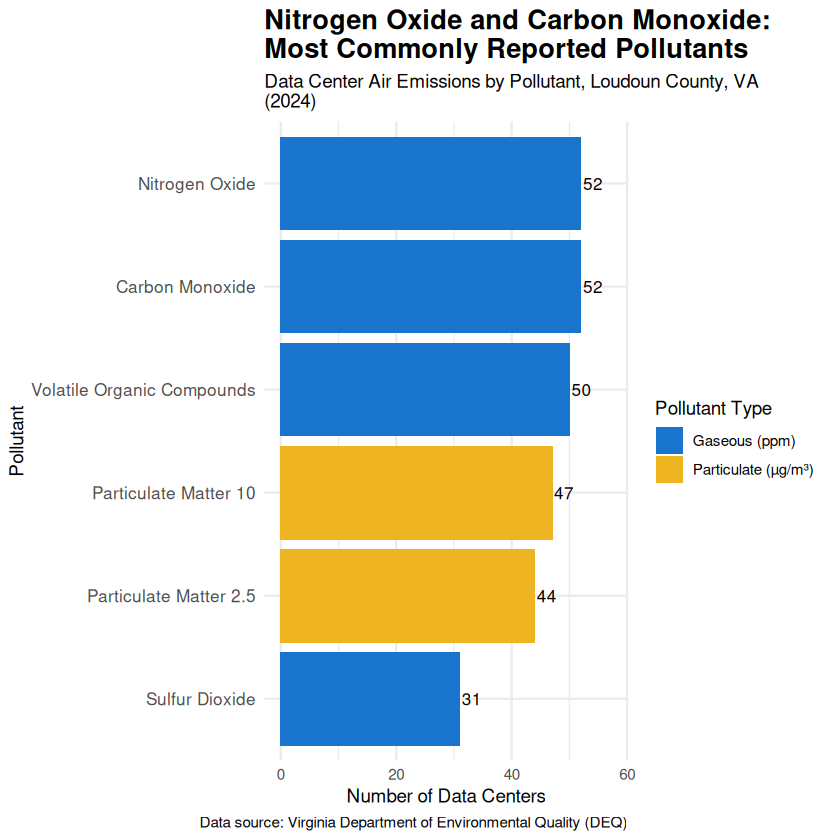

In [11]:
# VISUALIZATION 1: Distribution 

# Summarize the data

facility_counts <- air_emissions_joined %>%
  filter(!is.na(emission_value)) %>%      # selects the values that are NOT missing/excludes missing emissions
  filter(pollutant_name %in% c("Carbon Monoxide", "Nitrogen Oxide", "Sulfur Dioxide", "Volatile Organic Compounds", "Particulate Matter 10", "Particulate Matter 2.5")) %>% # excludes "Particulate Matter"  
  group_by(pollutant_name) %>%           
  summarise(num_datacenters = n_distinct(name), .groups = "drop") # removes the grouping after summarizing, so the output is a regular, ungrouped data frame; n_distinct is part of the dplyr package and counts the number of unique values in a vector

facility_counts


viz1 <- ggplot(facility_counts,
                aes(x = reorder(pollutant_name, num_datacenters), # reorder() to change the order of the factor levels
                    y = num_datacenters,
                    fill = ifelse(pollutant_name %in% 
                                  c("Carbon Monoxide", "Nitrogen Oxide",
                                    "Sulfur Dioxide", "Volatile Organic Compounds"),
                                  "Gaseous Pollutants",
                                  "Particulate Matter"))) +
  geom_col() +                            # geom_col()is part of the ggplot2 package 
  geom_text(aes(label = num_datacenters), # geom_text()is part of the ggplot2 package
            hjust = -0.1,
            size = 3.5) +
  scale_fill_manual(    # scale_fill_manual()is part of the ggplot2 package 
    values = c(
      "Gaseous Pollutants" = "dodgerblue3",
      "Particulate Matter" = "goldenrod2"), 
      labels = c("Gaseous (ppm)", "Particulate (µg/m³)"),
      name = "Pollutant Type"
  ) +
  coord_flip() +   # coord_flip()is part of the ggplot2 package
  labs(            # labs() is part of the ggplots2 package
    title = "Nitrogen Oxide and Carbon Monoxide:\nMost Commonly Reported Pollutants",  
    subtitle = str_wrap("Data Center Air Emissions by Pollutant, Loudoun County, VA (2024)", width = 60), #str_wrap() is part of the stringr package, used so titles and subtitles don't run off the page
    x = "Pollutant",
    y = "Number of Data Centers",
    caption = "Data source: Virginia Department of Environmental Quality (DEQ)"
  ) +
  theme_minimal() + # theme_minimal is part of the ggplot2 package and applies a clean, simplified visual style to the plot
  theme(
    axis.text.y = element_text(size = 10),
    plot.title = element_text(size = 16, face = "bold")
  ) +
  ylim(0, max(facility_counts$num_datacenters) * 1.1)

viz1

# Save final viz1 figure to outputs folder

ggsave("/home/user/Capstone/data_center_research/outputs/emissions_bar_chart.png", plot = viz1, width = 11, height = 7, dpi = 300)


<span style='font-size:large'>**Anaylsis and Visualization \#1 Findings:**</span><span style='font-size:large'> </span>

This bar chart shows the number of data centers in Loudoun County, VA emitting each pollutant in 2024. Among gaseous pollutants, nitrogen oxide and carbon monoxide are emitted by the greatest number of facilities; for particulate matter, the number of data centers emitting PM10 and PM2.5 is approximately the same. This visualization highlights which emissions may require closer monitoring given the higher number of data centers emitting those pollutants.



Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


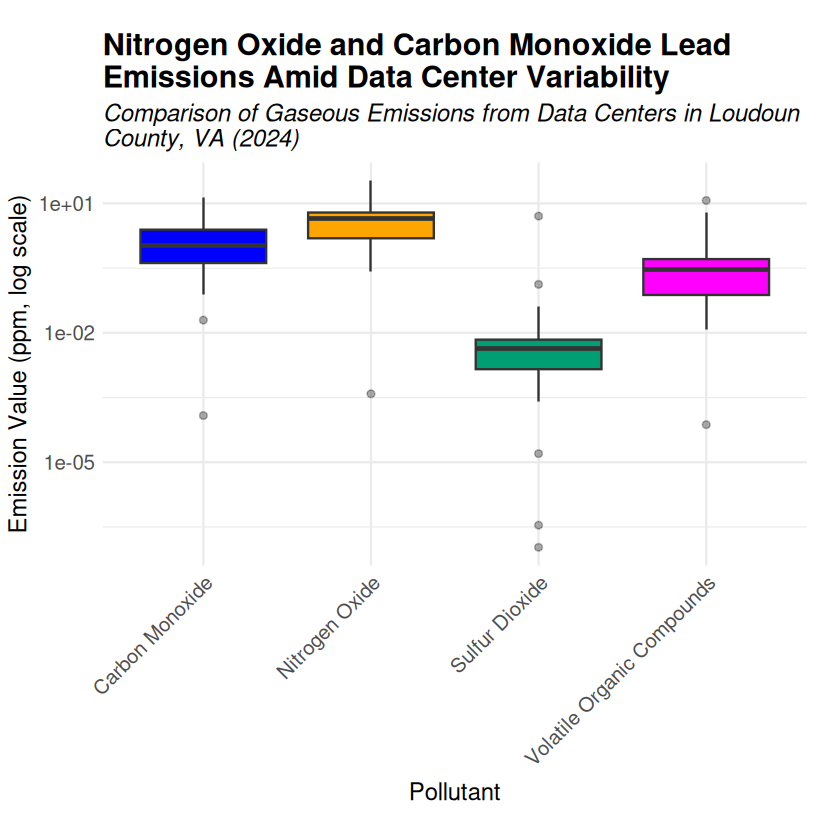

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


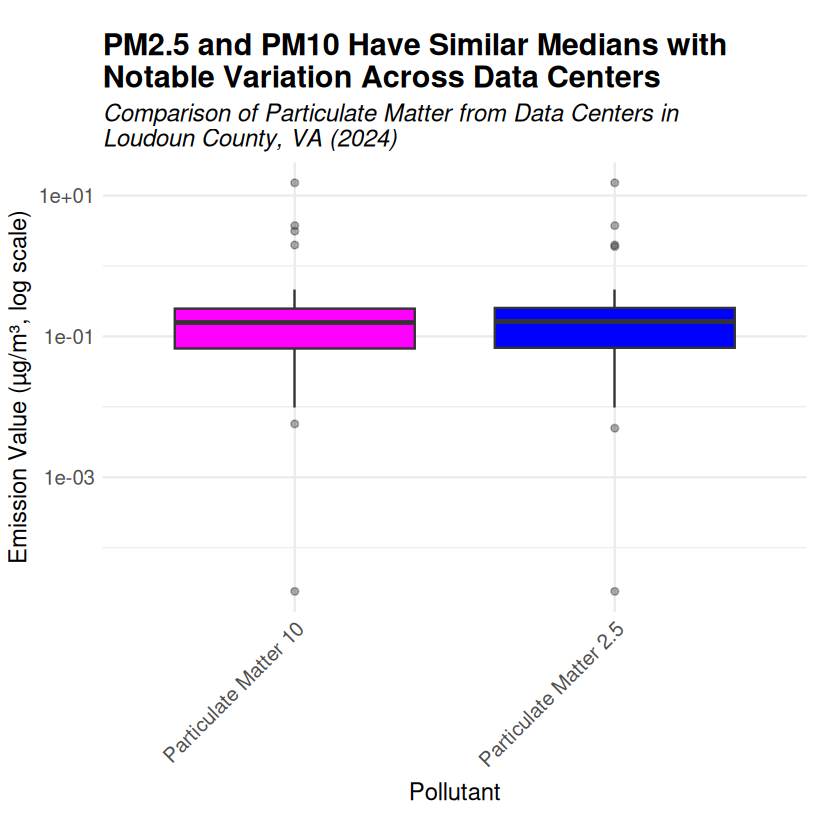

In [12]:
# VISUALIZATION 2: Relationship or Comparison


# Create two different datasets based on units of measurements
# Add units of measurement

gas_df <- air_emissions_joined %>%
  filter(pollutant_name %in% c("Carbon Monoxide",
                               "Nitrogen Oxide",
                               "Sulfur Dioxide",
                               "Volatile Organic Compounds"))

pm_df <- air_emissions_joined %>%
  filter(pollutant_name %in% c("Particulate Matter 2.5",
                               "Particulate Matter 10"))

#  Create Boxplot by Measurement Unit for gaseous pollutants, use log scale

viz2_gas <- ggplot(gas_df,
                   aes(x = pollutant_name,
                       y = emission_value,
                       fill = pollutant_name)) +
  geom_boxplot(outlier.alpha = 0.4) +
  scale_y_log10() +
  scale_fill_manual(values = c(
    "Carbon Monoxide" = "blue",   
    "Nitrogen Oxide" = "orange",    
    "Sulfur Dioxide" = "#009E73",     
    "Volatile Organic Compounds" = "magenta"  
  )) +
  labs(
    title = str_wrap ("Nitrogen Oxide and Carbon Monoxide Lead Emissions Amid Data Center Variability", width = 45),
    subtitle = str_wrap ("Comparison of Gaseous Emissions from Data Centers in Loudoun County, VA (2024)", width = 60),  
    x = "Pollutant",
    y = "Emission Value (ppm, log scale)"
  ) +
  theme_minimal() +
  theme(
  plot.margin = margin(t = 20, r = 20, b = 20, l = 5)
  )+
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "italic"),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14)
  )

# Create Boxplot by Measurement Unit for PM 2.5, and PM 10

viz2_pm <- ggplot(pm_df,
                  aes(x = pollutant_name,
                      y = emission_value,
                      fill = pollutant_name)) +
  geom_boxplot(outlier.alpha = 0.4) +
  scale_y_log10() +
  scale_fill_manual(values = c(                   
    "Particulate Matter 2.5" = "blue",               
    "Particulate Matter 10" = "magenta"                 
  )) +
  labs(
    title = str_wrap ("PM2.5 and PM10 Have Similar Medians with Notable Variation Across Data Centers", width = 45),
    subtitle = str_wrap ("Comparison of Particulate Matter from Data Centers in Loudoun County, VA (2024)", width = 60),  
    x = "Pollutant",
    y = "Emission Value (µg/m³, log scale)"
  ) +
  theme_minimal() +
  theme(
  plot.margin = margin(t = 20, r = 20, b = 20, l = 5)
  )+
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "italic"),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) 

viz2_gas
viz2_pm


# Save final viz2 figures to outputs folder

ggsave("/home/user/Capstone/data_center_research/outputs/gaseous_emissions_boxplot.png", plot = viz2_gas, width = 11, height = 7, dpi = 300)

ggsave("/home/user/Capstone/data_center_research/outputs/particulate_matter_emissions_boxplot.png", plot = viz2_pm, width = 11, height = 7, dpi = 300)


<span style='font-size:large'>**Anaylsis and Visualization \#2 Findings:**</span><span style='font-size:large'> </span>

The boxplots show the distribution of emission values for pollutants across all data centers in Loudoun County in 2024. Among gaseous pollutants, carbon monoxide and nitrogen oxide exhibit higher median emissions \(log scale\), indicating that these pollutants are more consistently emitted at elevated levels across data centers; particulate matters PM 2.5 and PM 10 have approximately equal median emissions \(log scale\). While the variabilty is similar across pollutant types, some data centers appear to be extreme emitters of specific pollutants, which may warrant further investigation.



In [16]:
#Import CSV file on data centers in Virginia
#data_centers <- read.csv(here("data", "processed", "pec_data_centers.csv"))
data_centers <- read.csv("data/processed/pec_data_centers.csv")

#show first 10 rows
head(data_centers, 10)

,OBJECTID,PEC_ID,Locality,Name,Owner_Applicant,Street_Address,Parcel_ID,Acres,Building_Sq_Ft,MW_reported,⋯,Build_Status,Notes,Tax_Map_link,Source_link,Lat,Long,Date_Updated,Updated_By,Lat1,Watershed
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<lgl>
1,1,PEC-CAR-0001/PEC-SPO-0003,Caroline County,Mattameade Tech Campus,Amazon Data Services Inc,Stonewall Jackson Road just east of the Mudd Tavern,27-A-4A,916.07,"4,500,000",NA,⋯,Proposed,Sister property to Spotsylvania campus- represents total square footage,,https://co.caroline.va.us/DocumentCenter/View/7255/RZ-02-2023-Orrock-Tech-Camus?bidId=,38.11465,-77.49115,2024-04-10,SEP,38.11465,NA
2,2,PEC-CAR-0002,Caroline County,VALCO Data Center Park,VALCO CAROLINE COUNTY,Mt Airy Road,80-A-43,855.00,"1,216,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",,https://co.caroline.va.us/AgendaCenter/ViewFile/Item/5593?fileID=9447,37.92410,-77.54387,2024-04-10,SEP,37.92410,NA
3,3,PEC-CAR-0003,Caroline County,Carmel Church Data Hub,W & F PARTNERS,Welcom Way Dr,82-14-A,97.00,"1,600,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",,https://co.caroline.va.us/DocumentCenter/View/9366/RZ-03-2023--Carmel-Church-Data-Hub,37.93933,-77.47797,2024-04-10,SEP,37.93933,NA
4,4,PEC-CHE-0001,Chesterfield County,Digital Fortress: Richmond,CHIRISA RICHMOND LLC,1401 MEADOWVILLE TECH PARKWAY,823657720300000,74.80,"242,042",25,⋯,Existing,Formerly a Capital One data center - vacated and for sale,https://www.chesterfield.gov/828/Real-Estate-Assessment-Data#/Details/823657720300000,,37.36048,-77.32741,2024-04-10,SEP,37.36048,NA
5,5,PEC-CHE-0002,Chesterfield County,Virginia Information Technologies Agency,SLK GLOBAL SOLUTIONS AMERICA,11751 MEADOWVILLE LANE,822656429800000,28.14,"192,195",NA,⋯,Existing,,https://www.chesterfield.gov/828/Real-Estate-Assessment-Data#/Details/822656429800000,,37.36041,-77.33178,2024-04-10,SEP,37.36041,NA
6,6,PEC-CUL-0001,Culpeper County,Equinix,EQUINIX LLC,18155 TECHNOLOGY DR,51-83A1,30.12,"370,000",NA,⋯,Existing,,https://gis.vgsi.com/culpeperva/Parcel.aspx?pid=10680,,38.45494,-77.97828,2024-04-10,SEP,38.45494,NA
7,7,PEC-CUL-0002,Culpeper County,SWIFT,,,51 83F,NA,"90,000",NA,⋯,Existing,,,,38.45554,-77.98348,2024-04-10,SEP,38.45554,NA
8,8,PEC-CUL-0003,Culpeper County,Cielo Digital Infrastructure,Cielo Digital Infrastructure,Cielo Digital Infrastructure,41-110,120.89,"1,400,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",https://gis.vgsi.com/culpeperva/Parcel.aspx?pid=3148,http://go.boarddocs.com/va/ccva/Board.nsf/goto?open&id=CWBKLL525B17,38.46679,-77.96353,2024-04-10,SEP,38.46679,NA
9,9,PEC-CUL-0004,Culpeper County,CloudHQ,CloudHQ,14521 MCDEVITT DR,41-106D,98.56,"2,100,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",https://gis.vgsi.com/culpeperva/Parcel.aspx?pid=21853,"https://www.culpeperva.org/properties/cloudhq-culpeper/#:~:text=CloudHQ%2C%20a%20global%20data%20center,of%20critical%20IT%20load%20power.",38.46164,-77.97762,2024-04-10,SEP,38.46164,NA


In [17]:
# Get the dimensions of the dataframe
dim(data_centers)

# Examine the variables of the dataset
names(data_centers)

# Examine the structure of the dataset
str(data_centers)

[1] 416  21

[1] "OBJECTID"          "PEC_ID"            "Locality"         
 [4] "Name"              "Owner_Applicant"   "Street_Address"   
 [7] "Parcel_ID"         "Acres"             "Building_Sq_Ft"   
[10] "MW_reported"       "Construction_Type" "Build_Status"     
[13] "Notes"             "Tax_Map_link"      "Source_link"      
[16] "Lat"               "Long"              "Date_Updated"     
[19] "Updated_By"        "Lat1"              "Watershed"

'data.frame':	416 obs. of  21 variables:
 $ OBJECTID         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ PEC_ID           : chr  "PEC-CAR-0001/PEC-SPO-0003" "PEC-CAR-0002" "PEC-CAR-0003" "PEC-CHE-0001" ...
 $ Locality         : chr  "Caroline County" "Caroline County" "Caroline County" "Chesterfield County" ...
 $ Name             : chr  "Mattameade Tech Campus" "VALCO Data Center Park" "Carmel Church Data Hub" "Digital Fortress: Richmond" ...
 $ Owner_Applicant  : chr  "Amazon Data Services Inc" "VALCO CAROLINE COUNTY" "W & F PARTNERS" "CHIRISA RICHMOND LLC" ...
 $ Street_Address   : chr  "Stonewall Jackson Road just east of the Mudd Tavern" "Mt Airy Road" "Welcom Way Dr" "1401 MEADOWVILLE TECH PARKWAY" ...
 $ Parcel_ID        : chr  "27-A-4A" "80-A-43" "82-14-A" "823657720300000" ...
 $ Acres            : num  916.1 855 97 74.8 28.1 ...
 $ Building_Sq_Ft   : chr  "4,500,000" "1,216,000" "1,600,000" "242,042" ...
 $ MW_reported      : num  NA NA NA 25 NA NA NA NA NA NA ...
 $ Construction_Type

In [18]:
#Create new dataframe
data_centers_clean <- as.data.frame(data_centers)

#Rename variables
data_centers_clean <- data_centers_clean %>%
  rename(
    object_id = OBJECTID,
    locality = Locality,
    name = Name,
    owner_applicant = Owner_Applicant,
    street_address = Street_Address,
    construction_type = Construction_Type,
    build_status = Build_Status,
    lat = Lat,
    long = Long,
  )


In [19]:
# Examine rows with missing longitude and latitude coordinates, blank space after the comma means "keep all columns"

data_centers_clean[is.na(data_centers_clean$long) | is.na(data_centers_clean$lat), ]

# Keep rows where long and lat exists

data_centers_clean <- data_centers_clean %>%
  filter(!is.na(long) & !is.na(lat))

# Can disregard #399 and #411 as they are proposed and we only want existing data centers; will filter for existing data centers next  

,object_id,PEC_ID,locality,name,owner_applicant,street_address,Parcel_ID,Acres,Building_Sq_Ft,MW_reported,⋯,build_status,Notes,Tax_Map_link,Source_link,lat,long,Date_Updated,Updated_By,Lat1,Watershed
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<lgl>
399,458,PEC-LDN-0132A,Loudoun County,PROJECT ASPEN,HAYDEN TECHNOLOGIES LLC,20491 GOOSE LANDING LN,194498227000,0.00,324890,NA,⋯,Proposed,,https://reparcelasmt.loudoun.gov/pt/Datalets/Datalet.aspx?UseSearch=no&mode=profileall&pin=194498227000&jur=107&taxyr=2024,https://loudouncountyvaeg.tylerhost.net/prod/selfservice#/plan/e48043e8-fdbb-4e91-aa87-60d35cb71173?tab=attachments,NA,-77.53495,2025-08-11,SEP,NA,NA
411,475,PEC-LDN-0157,Loudoun County,MERCURE BUSINESS PARK LOT 22,L22 LLC/ John Cox,"44211 MERCURE CIR , STERLING",091493983000,5.49,"95,658",NA,⋯,Proposed,Currently flex warehouse. Current building completed in 2022,https://reparcelasmt.loudoun.gov/pt/Datalets/Datalet.aspx?UseSearch=no&mode=profileall&pin=091493983000&jur=107&taxyr=2025,https://loudouncountyvaeg.tylerhost.net/prod/selfservice#/plan/a037a799-691c-42c4-a3fa-dd41c9dfa911?tab=attachments,NA,NA,2025-10-17,SEP,NA,NA


In [20]:
#Select only relevant columns and rows
data_centers_clean <- data_centers_clean %>%
    select(object_id, locality, name, street_address, owner_applicant, construction_type, build_status,lat, long) %>%
    filter(locality == "Loudoun County")%>% # keep only Loudoun County rows
    filter(build_status == "Existing")   # keep only Existing rows

data_centers_clean

object_id,locality,name,street_address,owner_applicant,construction_type,build_status,lat,long
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
72,Loudoun County,NV-8 CYRUSONE,45905 MARIES RD,C1 NORTHERN VIRGINIA - STERLING VIII LLC,Complete,Existing,39.02125,-77.41337
73,Loudoun County,CYXTERA DC2 COLOCATION,45901 NOKES BLVD,MEDINA DC 2 ASSETS LLC,Complete,Existing,39.02325,-77.41318
75,Loudoun County,MARIES TECH PARK LLC,45761 MARIES RD,Amazon Data Services Inc,Complete,Existing,39.02400,-77.41950
76,Loudoun County,45845 NOKES BLVD,45845 NOKES BLVD,MEDINA DC 2 ASSETS LLC,Complete,Existing,39.02387,-77.41527
77,Loudoun County,C1 NORTHERN VA - STERLING I-III,21111 Ridgetop,CyrusOne,Complete,Existing,39.02607,-77.41454
78,Loudoun County,CYXTERA COLOCATION,21110 RIDGETOP CIR,MEDINA DC 2 ASSETS LLC,Complete,Existing,39.02480,-77.41233
79,Loudoun County,Vantage V2 Campus 22318 Glenn Drive,22435 GLENN DR,VANTAGE DATA CENTERS VA2 LLC,Complete,Existing,38.99797,-77.43019
80,Loudoun County,CPUS STERLING LP,45900 PATHFINDER PLZ,CPUS STERLING LP,Complete,Existing,38.98775,-77.41086
81,Loudoun County,23005 INTERNATIONAL DR,23005 INTERNATIONAL DR,DULLES NCP II LLC,Complete,Existing,38.98000,-77.42562


<span style='font-size:large'>**Exploratory Data Analysis:**</span><span style='font-size:large'> </span>

The original data center dataset contained 416 observations and 21 variables across Virginia. After renaming variables, removing observations with missing geographic coordinates, and selecting relevant fields, the dataset was refined to include only existing facilities located in Loudoun County. This process resulted in 119 data centers with complete spatial information for mapping facility locations.

This comparison highlights an important distinction: while Loudoun County hosts a large number of operational data centers \(119 in this dataset\), less than half are represented in emissions reporting data as reflected in the joined air emissions dataset above \(52 in that dataset\). This gap suggests that emissions data capture only a subset of facilities—possibly due to reporting requirements, operational differences \(e.g. use of Tier 2 vs. Tier 4 diesel generators\), or emissions thresholds.


In [21]:
# Standarize the addresses in the air_emissions_joined and data_centers_clean (PEC) datasets

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = address %>%
           str_to_lower() %>%
          str_trim() %>%
          str_replace_all("\\.", "") %>%
          str_replace_all(" pl$", " plaza") %>%
          str_replace_all(" dr$", " drive") %>%
          str_replace_all(" rd$", " road") %>%
          str_replace_all(" ln$", " lane") %>%
          str_replace_all(" cir$", " circle") %>%
          str_replace_all(" pkwy$", " parkway"))

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = street_address %>%
          str_to_lower() %>%
          str_trim() %>%
          str_replace_all("\\.", "") %>%
          str_replace_all(" pl$", " plaza") %>%
          str_replace_all(" dr$", " drive") %>%
          str_replace_all(" rd$", " road") %>%
          str_replace_all(" ln$", " lane") %>%
          str_replace_all(" cir$", " circle") %>%
          str_replace_all(" blvd$", " boulevard") %>%
          str_replace_all(" pkwy$", " parkway"))

# Manually add in missing address

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = address_clean %>%
           str_replace_all(" plz$", " plaza") %>%
           str_replace_all("round table", "roundtable"))

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = address_clean %>%
           str_replace_all(" plz$", " plaza") %>%
           str_replace_all("round table", "roundtable"))

data_centers_clean <- data_centers_clean %>%
 mutate(address_clean = case_when(
  address_clean == "45900n pathfinder plaza" ~ "45900 pathfinder way",
   TRUE ~ address_clean
  ))

#  Manually remove addresses 

air_emissions_joined <- air_emissions_joined %>%
  filter(!address_clean %in% c(
    "14725 lee road",
    "14901 conference center drive",
    "4030 lafayette center dr ste a",
    "43673 john mosby highway"
   
  ))

data_centers_clean <- data_centers_clean %>%
  filter(!address_clean %in% c(
    "14725 lee road",
    "14901 conference center drive",
    "4030 lafayette center dr ste a",
    "43673 john mosby highway"
  ))

# Standardize Pathfinder address in emissions dataset
air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45900") &
    str_detect(address_clean, "pathfinder") ~ "45900 pathfinder plaza",
    TRUE ~ address_clean
  ))

# Standardize Pathfinder address in data centers dataset
data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45900") &
    str_detect(address_clean, "pathfinder") ~ "45900 pathfinder plaza",
    TRUE ~ address_clean
  ))


# Standardize Kipper address in emissions dataset
air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^22370") &
    str_detect(address_clean, "kipper") ~ "22370 kipper drive",
    TRUE ~ address_clean
  ))

# Standardize Kipper address in data centers dataset
data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^22370") &
    str_detect(address_clean, "kipper") ~ "22370 kipper drive",
    TRUE ~ address_clean
  ))

# Standarize Prologis address in emissions dataset

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45220") &
    str_detect(address_clean, "prolog") ~ "45220 prologis plaza",
    TRUE ~ address_clean
  ))

# Standarize Prologis address in data centers dataset in data centers dataset

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45220") &
    str_detect(address_clean, "prolog") ~ "45220 prologis plaza",
    TRUE ~ address_clean
  ))

# Standarize relocation address missing full address in emissions dataset

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^relocation drive$") ~ "22715 relocation drive",
    TRUE ~ address_clean
  ))

# Standarize relocation address missing full address in data centers dataset

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^relocation drive$") ~ "22715 relocation drive",
    TRUE ~ address_clean
  ))

# Check what doesn't match
setdiff(air_emissions_joined$address_clean,
        data_centers_clean$address_clean)


[1] "22995 wilder court"           "21635 red rum drive"         
 [3] "22001 loudoun county parkway" "22080 pacific blvd"          
 [5] "511 shaw road"                "42911 arcola road"           
 [7] "23825 erins run drive"        "22890 platform plaza"        
 [9] "22210 loudoun county parkway" "22588 relocation drive"      
[11] "21099 atlantic boulevard"     "25430 sutton bay plaza"      
[13] "28755 relocation drive"       "22426 lockridge road"        
[15] "42575 arcola blvd"            "3980 virginia mallory drive" 
[17] "19935 sycolin road"           "44254 import plaza"          
[19] "24282 quail ridge lane"       "45781 maries road"

In [22]:
setdiff(data_centers_clean$address_clean,
        air_emissions_joined$address_clean)

[1] "45901 nokes boulevard"         "45761 maries road"            
 [3] "45845 nokes boulevard"         "21111 ridgetop"               
 [5] "21110 ridgetop circle"         "23005 international drive"    
 [7] "22916 international drive"     "22900 platform plaza"         
 [9] "22811 international drive"     "22810 international drive"    
[11] "44901 russell branch parkway"  "20935 loudoun county parkway" 
[13] "21529 beaumeade circle"        "45305 w severn way"           
[15] "45360 w severn way"            "1304 squire ct"               
[17] "21641 charles view drive"      "22340 dresden st"             
[19] "22080 pacific boulevard"       "45200 vantage data plaza"     
[21] "22125 broderick drive"         "22630 dulles summit ct"       
[23] "22745 relocation drive"        "22651 dulles summit ct"       
[25] "22574 pacific boulevard"       "22520 randolph drive"         
[27] "22631 dulles summit ct"        "22580 relocation drive"       
[29] "1506 moran road"               "22350 kipper drive"           
[31] "22995 wilder ct"               "44521 hastings drive"         
[33] "44490 chilum plaza"            "44520 hastings drive"         
[35] "21571 beaumeade circle"        "44790 performance circle"     
[37] "44862 interconnection plaza"   "21744 sir timothy drive"      
[39] "44621 waxpool road"            "44631 waxpool road"           
[41] "21310 beaumeade circle"        "21800 beaumeade circle"       
[43] "21745 sir timothy drive"       "21320 beaumeade circle"       
[45] "21625 gresham drive"           "21701 filigree ct"            
[47] "44757 roundtable plaza"        "44655 quality tech lane"      
[49] "44675 quality tech lane"       "21821 uunet drive"            
[51] "21830 uunet drive"             "21838 uunet drive"            
[53] "21735 red rum drive"           "21630 red rum drive"          
[55] "22271 shellhorn road"          "43881 devin shafron drive"    
[57] "43940 digital loudoun plaza"   "43791 devin shafron drive"    
[59] "43831 devin shafron drive"     "43830 devin shafron drive"    
[61] "43915 devin shafron drive"     "25316 prediction lane"        
[63] "25800 sutton bay plaza"        "42949 fadeley lane"           
[65] "20680 celtic park drive"       "41840 growth mindset lane"    
[67] "19540 compass creek parkway"   "24244 quail ridge lane"       
[69] "24214 quail ridge lane"        "22200 loudoun county parkway" 
[71] "21215 atlantic boulevard"      "21205 atlantic boulevard"     
[73] "21195 atlantic boulevard"      "22285 lockridge road"         
[75] "22271 lockridge road"          "25500 meadowdale drive"       
[77] "43649 light speed plaza"       "23845 erins run drive"        
[79] "43321 data drive"              "19275 compass creek pkwy se"  
[81] "19265 compass creek parkway"   "24400 howling rooster lane"   
[83] "22760 pacific blv"             "45111 loudoun downs lane"     
[85] "22321 pacific blvd , sterling" "44351 import plaza"           
[87] "21340 pacific boulevard"       "44480 hastings drive"         
[89] "21625 red rum drive"           "42247 thunderball drive"

In [23]:
length(setdiff(data_centers_clean$address_clean,
               air_emissions_joined$address_clean))

# Address matching between the Virginia data center registry and the 2024 air emissions inventory identified 91 data center facilities without a corresponding emissions record, suggesting either non-reporting sites, facilities operating below regulatory thresholds, or inconsistencies in address formatting between datasets.

[1] 90

In [24]:
length(setdiff(air_emissions_joined$address_clean,
               data_centers_clean$address_clean))

# 2 addresses appear in the emissions dataset but do NOT appear in your data center dataset.

[1] 20

In [25]:
# Join the two datasets using the address_clean field so that the resulting air_emissions_joined dataset includes longitude and latitude coordinates.
# Add a column on air emissions to data_centers_clean joining by street_address 


# Check that address_clean exists in both datasets
"address_clean" %in% colnames(air_emissions_joined)
"address_clean" %in% colnames(data_centers_clean)

# Create one address per data center in the data_centers_clean dataset removing duplicates
data_centers_coords <- data_centers_clean %>%
  select(address_clean, lat, long) %>%
  distinct(address_clean, .keep_all = TRUE)

# Check that each address appears only once in the data_centers_coords dataset
data_centers_coords %>%
  count(address_clean) %>%
  filter(n > 1)

# Join air_sites_cleanand air_sites_emissions_clean

emissions_coordinates_joined <- air_emissions_joined %>%
  left_join(data_centers_coords, by = "address_clean")

glimpse(emissions_coordinates_joined)

[1] TRUE

[1] TRUE

address_clean,n
<chr>,<int>


Rows: 262
Columns: 11
$ name              <chr> "Equinix LLC", "Equinix LLC", "Equinix LLC", "Equini…
$ city              <chr> "Ashburn", "Ashburn", "Ashburn", "Ashburn", "Ashburn…
$ address           <chr> "44470 Chilum Pl", "44470 Chilum Pl", "44470 Chilum …
$ principal_product <chr> "data center", "data center", "data center", "data c…
$ icis_id           <chr> "VA0000005110700820", "VA0000005110700820", "VA00000…
$ emissions_year    <int> 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024…
$ emission_value    <dbl> 0.55391400, 0.02376000, 0.02904000, 0.03062400, 0.10…
$ pollutant_name    <chr> "Nitrogen Oxide", "Particulate Matter", "Volatile Or…
$ address_clean     <chr> "44470 chilum plaza", "44470 chilum plaza", "44470 c…
$ lat               <dbl> 39.02221, 39.02221, 39.02221, 39.02221, 39.02221, 39…
$ long              <dbl> -77.46144, -77.46144, -77.46144, -77.46144, -77.4614…


In [26]:
# Check which addresses do not have lat and long

missing_coords <- emissions_coordinates_joined %>%
  filter(is.na(lat) | is.na(long)) %>%
  select(address_clean) %>%
  distinct()

missing_coords

address_clean
<chr>
22995 wilder court
21635 red rum drive
22001 loudoun county parkway
22080 pacific blvd
511 shaw road
42911 arcola road
23825 erins run drive
22890 platform plaza
22210 loudoun county parkway


In [27]:
# Manually add in missing coordinates

manual_coords <- tibble::tibble(
  address_clean = c(
    "22995 wilder court",
    "21635 red rum drive",
    "22001 loudoun county parkway",
    "22080 pacific blvd",
    "43673 john mosby highway",
    "511 shaw road",
    "42911 arcola road",
    "23825 erins run drive",
    "22890 platform plaza",
    "22210 loudoun county parkway",
    "22715 relocation drive", 
    "22588 relocation drive",
    "21099 atlantic boulevard",
    "28755 relocation drive",  
    "22426 lockridge road",
    "42575 arcola blvd",
    "19935 sycolin road",
    "44254 import plaza",
    "24282 quail ridge lane",
    "45781 maries road",
    "25430 sutton bay plaza"
   
      
  ),
  latitude = c(
    38.974,39.015966,39.01121,39.0094,38.9419, 39.0069,38.9517,39.058719,39.0142,
    39.068,33.006, 39.0016,39.0142,38.985,38.9959,38.9517772,39.0706627,39.0437,
    38.932,38.9716,38.927
  ),
  longitude = c(
    -77.447,-77.48158,-77.47120,-77.4485,-77.5306, -77.4107,-77.5341,-77.4327656,-77.4727,
    -77.491,-77.428, -77.4578,-77.4311,-77.458,-77.4124,-77.5341578,-77.6047138,-77.4875,
    -77.525,-77.6214,-77.534
  )
)


In [28]:
# Merge new coordinates with existing dataset

emissions_coordinates_joined <- emissions_coordinates_joined %>%
  left_join(manual_coords, by = "address_clean", suffix = c("", "_manual")) %>%
  mutate(
    lat = coalesce(lat, latitude),
    long = coalesce(long, longitude)
  ) %>%
  select(-latitude, -longitude)  # drop the temporary manual columns

In [29]:
# Double check that all addresses have latitude and longtitude

emissions_coordinates_joined %>%
  filter(is.na(lat) | is.na(long))

# Remove coordinates with NAs
emissions_tidy <- emissions_coordinates_joined %>%
  drop_na(lat, long)

emissions_tidy

# Check removal worked - second number should be smaller than the first one
nrow(emissions_coordinates_joined)
nrow(emissions_tidy)

sum(is.na(emissions_tidy$lat))

length(unique(emissions_tidy$address_clean))

name,city,address,principal_product,icis_id,emissions_year,emission_value,pollutant_name,address_clean,lat,long
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
Amazon Data Services Inc - IAD-134/135/136,Chantilly,3980 Virginia Mallory Drive,Data Center,VA0000005105974239,2024,6.655677000,Nitrogen Oxide,3980 virginia mallory drive,NA,NA
Amazon Data Services Inc - IAD-134/135/136,Chantilly,3980 Virginia Mallory Drive,Data Center,VA0000005105974239,2024,0.605380500,Volatile Organic Compounds,3980 virginia mallory drive,NA,NA
Amazon Data Services Inc - IAD-134/135/136,Chantilly,3980 Virginia Mallory Drive,Data Center,VA0000005105974239,2024,0.006277426,Sulfur Dioxide,3980 virginia mallory drive,NA,NA
Amazon Data Services Inc - IAD-134/135/136,Chantilly,3980 Virginia Mallory Drive,Data Center,VA0000005105974239,2024,2.275261500,Carbon Monoxide,3980 virginia mallory drive,NA,NA
Amazon Data Services Inc - IAD-134/135/136,Chantilly,3980 Virginia Mallory Drive,Data Center,VA0000005105974239,2024,0.217507500,Particulate Matter 10,3980 virginia mallory drive,NA,NA
Amazon Data Services Inc - IAD-134/135/136,Chantilly,3980 Virginia Mallory Drive,Data Center,VA0000005105974239,2024,0.217507500,Particulate Matter 2.5,3980 virginia mallory drive,NA,NA


name,city,address,principal_product,icis_id,emissions_year,emission_value,pollutant_name,address_clean,lat,long
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
Equinix LLC,Ashburn,44470 Chilum Pl,data center,VA0000005110700820,2024,0.55391400,Nitrogen Oxide,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,Ashburn,44470 Chilum Pl,data center,VA0000005110700820,2024,0.02376000,Particulate Matter,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,Ashburn,44470 Chilum Pl,data center,VA0000005110700820,2024,0.02904000,Volatile Organic Compounds,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,Ashburn,44470 Chilum Pl,data center,VA0000005110700820,2024,0.03062400,Sulfur Dioxide,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,Ashburn,44470 Chilum Pl,data center,VA0000005110700820,2024,0.10560000,Carbon Monoxide,44470 chilum plaza,39.02221,-77.46144
Equinix LLC,Ashburn,44470 Chilum Pl,data center,VA0000005110700820,2024,0.02376000,Particulate Matter 10,44470 chilum plaza,39.02221,-77.46144
22995 Wilder Court LLC,Dulles,22995 Wilder Court,Data Center,VA0000005110700839,2024,1.54100000,Nitrogen Oxide,22995 wilder court,38.97400,-77.44700
22995 Wilder Court LLC,Dulles,22995 Wilder Court,Data Center,VA0000005110700839,2024,0.07120000,Volatile Organic Compounds,22995 wilder court,38.97400,-77.44700
22995 Wilder Court LLC,Dulles,22995 Wilder Court,Data Center,VA0000005110700839,2024,0.04060000,Sulfur Dioxide,22995 wilder court,38.97400,-77.44700


[1] 262

[1] 256

[1] 0

[1] 46

<span style='font-size:large'>**Exploratory Data Analysis:**</span> 

After standardizing address fields and supplementing missing geographic coordinates, the datasets were successfully joined at the facility level. The resulting dataset includes 256 emission records across 46 unique data centers, indicating that each facility reports multiple pollutant types. Emissions are concentrated among a consistent set of pollutants—nitrogen oxides, volatile organic compounds, sulfur dioxide, carbon monoxide, and particulate matter \(PM10 and PM2.5\)—suggesting relatively uniform emission profiles across data center operations.



Reading layer `Loudoun_County_Boundary' from data source 
  `/home/user/Capstone/data_center_research/data/raw_data/Loudoun_County_Boundary.geojson' 
  using driver `GeoJSON'
Simple feature collection with 1 feature and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -77.9622 ymin: 38.84621 xmax: -77.32831 ymax: 39.3246
Geodetic CRS:  WGS 84


Reading layer `Loudoun_Water_Bodies' from data source 
  `/home/user/Capstone/data_center_research/data/raw_data/Loudoun_Water_Bodies.geojson' 
  using driver `GeoJSON'
Simple feature collection with 6042 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -77.95354 ymin: 38.83887 xmax: -77.31833 ymax: 39.32859
Geodetic CRS:  WGS 84


Warning message in scale_color_viridis_c(option = "viridis", trans = "log10", direction = -1, :
“log-10 transformation introduced infinite values.”


Warning message in scale_color_viridis_c(option = "viridis", trans = "log10", direction = -1, :
“log-10 transformation introduced infinite values.”


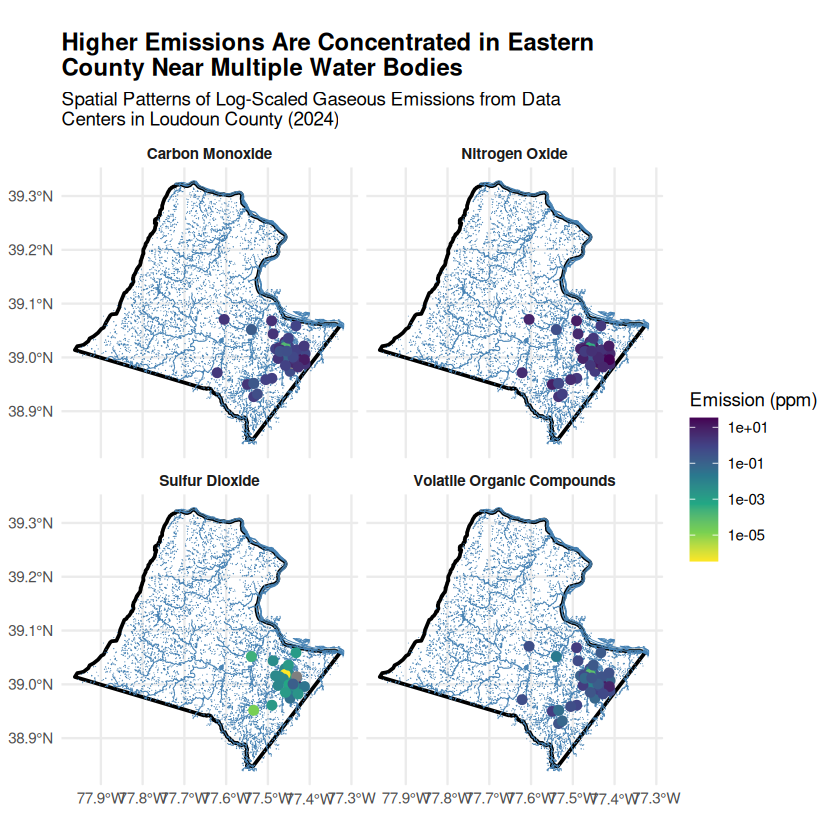

Warning message in scale_color_viridis_c(option = "viridis", trans = "log10", direction = -1, :
“log-10 transformation introduced infinite values.”


Warning message in scale_color_viridis_c(option = "viridis", trans = "log10", direction = -1, :
“log-10 transformation introduced infinite values.”


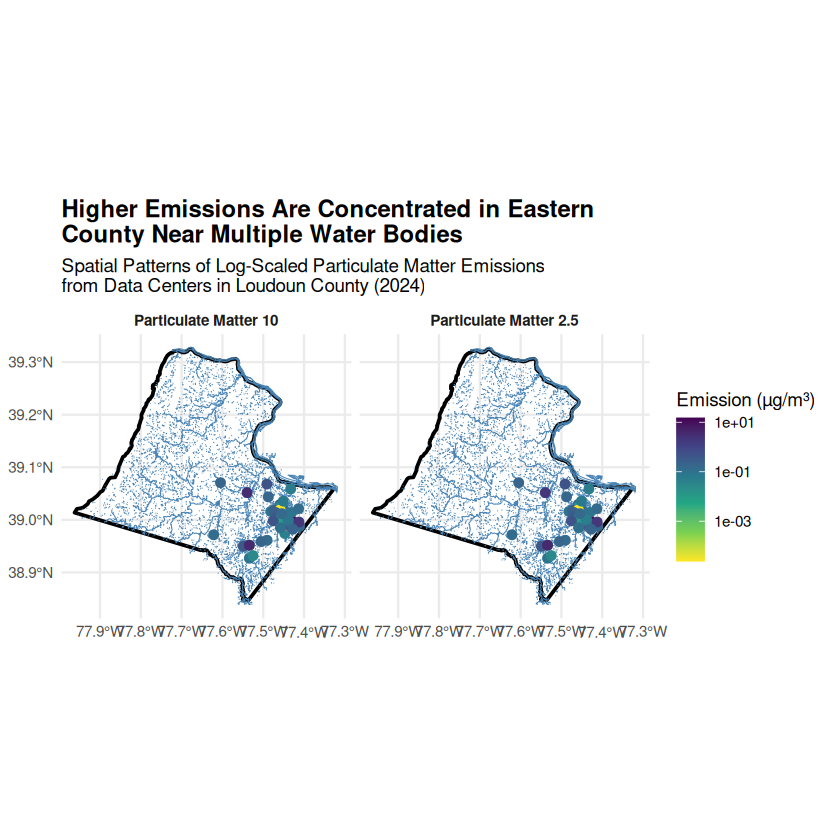

In [30]:
# Load the Loundoun boundary geojson file from local data
#boundary <- st_read(here("data", "raw_data", "Loudoun_County_Boundary.geojson"))
boundary <- st_read("data/raw_data/Loudoun_County_Boundary.geojson")

# Load the Loundoun waterbodies geojson file from local data
#water_bodies  <- st_read(here("data", "raw_data", "Loudoun_Water_Bodies.geojson"))
water_bodies <- st_read("data/raw_data/Loudoun_Water_Bodies.geojson")

  # Water bodies
  #geom_sf(
   # data = water_bodies,
   # fill = "lightblue",
   # color = "dodgerblue4",
   # alpha = 0.6
  #) 

# Convert points (latitude and longitude of data centers) to spatial features using st_as_sf()

emissions_sf <- st_as_sf(
  emissions_tidy,
  coords = c("long", "lat"),  # X first, Y second
  crs = 4326                  # WGS84 (standard GPS)
)

# Add units of measurement. 

emissions_sf <- emissions_sf %>%
  mutate(
    measurement_unit = case_when(
      pollutant_name %in% c("Carbon Monoxide",
                            "Nitrogen Oxide",
                            "Sulfur Dioxide",
                            "Volatile Organic Compounds") ~ "ppm",
      pollutant_name %in% c(
                            "Particulate Matter 2.5",
                            "Particulate Matter 10") ~ "µg/m³",
      TRUE ~ NA_character_
    )
  )

# Create combined facet label
emissions_sf <- emissions_sf %>%
  mutate(pollutant_label = paste0(pollutant_name, "(", measurement_unit, ")")) # 

# Convert to factor with specific order
emissions_sf <- emissions_sf %>%
  mutate(pollutant_label = factor(  # Must create pollutant_label first. Cannot factor it before it exists.)
    pollutant_label,
    levels = c(
      "Carbon Monoxide (ppm)",
      "Nitrogen Oxide (ppm)",
      "Sulfur Dioxide (ppm)",
      "Volatile Organic Compounds (ppm)",
      "Particulate Matter 2.5 (µg/m³)",
      "Particulate Matter 10 (µg/m³)"
    )
  ))

# Split datasets by measurement unit

emissions_gas <- emissions_sf %>%
  filter(measurement_unit == "ppm")

emissions_pm <- emissions_sf %>%
  filter(measurement_unit == "µg/m³")

# Map Gaseous Emissions 

viz3_map_gas <- ggplot() +
  geom_sf(data = boundary, fill = NA, color = "black", linewidth = 0.8) +
  geom_sf(data = water_bodies, fill = "lightblue", color = "steelblue", alpha = 0.2) +
  geom_sf(
    data = emissions_gas,
    aes(color = emission_value),
    size = 2
  ) +
 facet_wrap(~ pollutant_name) +
  scale_color_viridis_c(
    option = "viridis",
    trans = "log10",
    direction = -1, # reverses color scheme so dark color can reflect higher emission levels
    name = "Emission (ppm)"
  ) +
  theme_minimal() +
  labs(
    title = str_wrap ("Higher Emissions Are Concentrated in Eastern County Near Multiple Water Bodies", width = 45),
    subtitle = str_wrap ("Spatial Patterns of Log-Scaled Gaseous Emissions from Data Centers in Loudoun County (2024)", width = 60) 
  ) +
  theme(
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 14)
  )

print(viz3_map_gas)

# Map Particulate Emissions 

viz3_map_pm <- ggplot() +
  geom_sf(data = boundary, fill = NA, color = "black", linewidth = 0.8) +
  geom_sf(data = water_bodies, fill = "lightblue", color = "steelblue", alpha = 0.2) +
  geom_sf(
    data = emissions_pm,
    aes(color = emission_value),
    size = 2
  ) +
  facet_wrap(~ pollutant_name) +
  scale_color_viridis_c(
    option = "viridis",
    trans = "log10",
    direction = -1, # reverses color scheme so dark color can reflect higher emission levels
    name = "Emission (µg/m³)"
  ) +
  theme_minimal() +
  labs(
    title = str_wrap ("Higher Emissions Are Concentrated in Eastern County Near Multiple Water Bodies", width = 45),
    subtitle = str_wrap ("Spatial Patterns of Log-Scaled Particulate Matter Emissions from Data Centers in Loudoun County (2024)", width = 60) 
  ) +
  theme(
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 14)
  )

print(viz3_map_pm)

# Save final viz3 figure to outputs folder

ggsave("/home/user/Capstone/data_center_research/outputs/emissions_map_gas.png", plot = viz3_map_gas, width = 10, height = 7, dpi = 300)

ggsave("/home/user/Capstone/data_center_research/outputs/emissions_map_particulate_matter.png", plot = viz3_map_pm, width = 10, height = 7, dpi = 300)



<span style='font-size:large'>**Anaylsis and Visualization Findings:** </span>

<span style='font-size:medium'>The spatial distribution maps indicate that reported emissions from data centers are concentrated in the eastern portion of Loudoun County, with several facilities located near water bodies. Higher emission values appear clustered in this area across multiple pollutants. These spatial patterns highlight areas where additional monitoring or environmental assessment may be appropriate given the proximity of emission sources to waterways.</span>



<span style='font-size:large'>**Final Analysis :**</span><span style='font-size:large'> </span>

<span style='font-size:medium'>This analysis identifies at least 52 data centers in Loudoun County, Virginia reporting air pollutant emissions in 2024. These facilities consistently emit a core set of pollutants—nitrogen oxides, carbon monoxide, and particulate matter \(PM10 and PM2.5\)—with most also emitting volatile organic compounds. Sulfur dioxide is less commonly reported but shows higher variability across facilities.</span>

<span style='font-size:medium'>Spatial patterns reveal a strong concentration of emitting data centers in eastern Loudoun County, where many are located near water bodies. While this study does not assess direct environmental impacts, the proximity of emissions sources to water resources highlights potential exposure pathways.</span>



<span style='font-size:large'>**Closing Thoughts:**</span>

<span style='font-size:medium'>The relatively small number of reporting facilities compared to the total number of data centers in the county suggests possible gaps in emissions reporting. As the industry continues to expand, further investigation into cumulative emissions and environmental implications is warranted.</span>
